# 01 数据清洗与样本构建




本部分完成数据读取、预处理、变量构造、样本筛选与异常值处理。


## 第一部分：数据获取与处理


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import importlib, plot_config
importlib.reload(plot_config)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

# 设置路径
DATA_PATH = 'data/processed/'
OUTPUT_PATH = 'output/'
import os
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, 'figures'), exist_ok=True)

# 读取数据
balance_sheet = pd.read_csv(os.path.join(DATA_PATH, 'balance_sheet_processed.csv'))
income_stmt = pd.read_csv(os.path.join(DATA_PATH, 'income_stmt_processed.csv'))
cashflow = pd.read_csv(os.path.join(DATA_PATH, 'cashflow_processed.csv'))
ownership = pd.read_csv(os.path.join(DATA_PATH, 'ownership_processed.csv'))
industry = pd.read_csv(os.path.join(DATA_PATH, 'industry_processed.csv'))
st_flag = pd.read_csv(os.path.join(DATA_PATH, 'st_flag.csv'))
m2 = pd.read_csv(os.path.join(DATA_PATH, 'm2_processed.csv'))

print('数据读取完成')
print('各数据表形状：')
print(f'资产负债表: {balance_sheet.shape}')
print(f'利润表: {income_stmt.shape}')
print(f'现金流量表: {cashflow.shape}')
print(f'股权性质: {ownership.shape}')
print(f'行业分类: {industry.shape}')
print(f'ST标记: {st_flag.shape}')
print(f'M2增长率: {m2.shape}')

Plot config initialized, English font: Arial
Plot config initialized, English font: Arial
数据读取完成
各数据表形状：
资产负债表: (117059, 8)
利润表: (117056, 4)
现金流量表: (71215, 6)
股权性质: (55716, 7)
行业分类: (56731, 5)
ST标记: (59138, 4)
M2增长率: (16, 3)


### 1.2 数据预处理与合并


In [3]:
# 统一列名并处理时间变量
def process_time(df, date_col):
    df['year'] = pd.to_datetime(df[date_col]).dt.year
    df['Accper'] = pd.to_datetime(df[date_col])
    return df

# 处理各数据表
balance_sheet = process_time(balance_sheet, 'Accper')
income_stmt = process_time(income_stmt, 'Accper')
cashflow = process_time(cashflow, 'Accper')
ownership = process_time(ownership, 'EndDate')
industry = process_time(industry, 'EndDate')
st_flag = process_time(st_flag, 'EndDate')

# 重命名股票代码列以统一
ownership = ownership.rename(columns={'Symbol': 'Stkcd'})
industry = industry.rename(columns={'Symbol': 'Stkcd'})
st_flag = st_flag.rename(columns={'Symbol': 'Stkcd'})

# 合并数据
# 首先合并财务报表数据
df = pd.merge(balance_sheet, income_stmt, on=['Stkcd', 'year', 'Accper', 'ShortName'], how='inner')
df = pd.merge(df, cashflow, on=['Stkcd', 'year', 'Accper', 'ShortName'], how='inner')

# 合并其他表时处理可能的重复列名
df = pd.merge(df, ownership, on=['Stkcd', 'year'], how='inner', suffixes=('', '_ownership'))
df = pd.merge(df, industry, on=['Stkcd', 'year'], how='inner', suffixes=('', '_industry'))
df = pd.merge(df, st_flag, on=['Stkcd', 'year'], how='inner', suffixes=('', '_st'))
df = pd.merge(df, m2, on=['year'], how='inner')

# 清理重复列名
for col in df.columns:
    if '_ownership' in col or '_industry' in col or '_st' in col:
        original_col = col.replace('_ownership', '').replace('_industry', '').replace('_st', '')
        if original_col in df.columns and original_col != col:
            df = df.drop(columns=[col])

print(f'合并后数据形状: {df.shape}')
print('\n数据基本信息:')
df.info()

合并后数据形状: (266446, 23)

数据基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266446 entries, 0 to 266445
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Stkcd                          266446 non-null  int64         
 1   ShortName                      266446 non-null  object        
 2   Accper                         266446 non-null  datetime64[ns]
 3   CurrentAssets                  260141 non-null  float64       
 4   NetFixedAssets                 265134 non-null  float64       
 5   TotalAssets                    266440 non-null  float64       
 6   CurrentLiabilities             260145 non-null  float64       
 7   TotalEquity                    266446 non-null  float64       
 8   year                           266446 non-null  int32         
 9   NetIncome                      266446 non-null  float64       
 10  Depreciation                   266020

### 1.3 变量构造


In [4]:
# 因变量：杠杆率 Lev
df['Lev'] = df['TotalLiabilities'] / df['TotalAssets'] if 'TotalLiabilities' in df.columns else (df['TotalAssets'] - df['TotalEquity']) / df['TotalAssets']

# 核心解释变量：净利润率 NPR
df['NPR'] = df['NetIncome'] / df['TotalAssets']

# 控制变量
# Size：总资产对数
df['Size'] = np.log(df['TotalAssets'])

# Tang：固定资产比例
df['Tang'] = df['NetFixedAssets'] / df['TotalAssets']

# Growth：总资产增长率（需要滞后一期）
df = df.sort_values(['Stkcd', 'year'])
df['TotalAssets_Lag'] = df.groupby('Stkcd')['TotalAssets'].shift(1)
df['Growth'] = (df['TotalAssets'] - df['TotalAssets_Lag']) / df['TotalAssets_Lag']

# NDTS：折旧与摊销比例
df['DepreciationTotal'] = df['Depreciation'] + df['Amortization_IntangibleAssets'] + df['Long-termDeferredExpenses']
df['NDTS'] = df['DepreciationTotal'] / df['TotalAssets']

# SOE：国有企业虚拟变量
df['SOE'] = df['soe_flag']

# 流动性（可选）
if 'CurrentAssets' in df.columns and 'CurrentLiabilities' in df.columns:
    df['Liq'] = df['CurrentAssets'] / df['CurrentLiabilities']

print('变量构造完成')
print('变量列表:', list(df.columns))

变量构造完成
变量列表: ['Stkcd', 'ShortName', 'Accper', 'CurrentAssets', 'NetFixedAssets', 'TotalAssets', 'CurrentLiabilities', 'TotalEquity', 'year', 'NetIncome', 'Depreciation', 'Amortization_IntangibleAssets', 'Long-termDeferredExpenses', 'EndDate', 'ActualControllerName', 'ActualControllerNatureID', 'EquityNature', 'soe_flag', 'IndustryName', 'IndustryCode', 'st_flag', 'date', 'm2_growth', 'Lev', 'NPR', 'Size', 'Tang', 'TotalAssets_Lag', 'Growth', 'DepreciationTotal', 'NDTS', 'SOE', 'Liq']


### 1.4 样本筛选


In [5]:
print('Sample screening process:')

# Keep an immutable snapshot for reproducibility.
df_raw = df.copy()
screening_steps = []


def record_step(step_name, data):
    screening_steps.append({
        'step': step_name,
        'obs_left': int(len(data)),
        'firms_left': int(data['Stkcd'].nunique())
    })


# Step 0: initial sample
record_step('Initial sample', df_raw)

# Step 1: remove financial firms (industry code starts with J)
df = df_raw.copy()
df['IndustryCode'] = df['IndustryCode'].astype(str).str.upper()
df = df[~df['IndustryCode'].str.startswith('J')]
record_step('Drop financial/insurance', df)

# Step 2: remove firms ever marked as ST/PT (conservative rule)
st_companies = df.loc[df['st_flag'] == 1, 'Stkcd'].unique()
df = df[~df['Stkcd'].isin(st_companies)]
record_step('Drop ST/PT firms', df)

# Step 3: remove insolvent observations (Lev > 1)
df = df[df['Lev'] <= 1]
record_step('Drop Lev > 1', df)

# Step 4: remove missing observations in key variables
key_vars = ['Lev', 'NPR', 'Size', 'Tang', 'Growth', 'NDTS', 'SOE']
df = df.dropna(subset=key_vars)
record_step('Drop missing key vars', df)

# Final sample
record_step('Final sample', df)

sample_info = pd.DataFrame(screening_steps)
sample_info['obs_dropped'] = sample_info['obs_left'].shift(1) - sample_info['obs_left']
sample_info.loc[0, 'obs_dropped'] = '-'
sample_info = sample_info[['step', 'obs_dropped', 'obs_left', 'firms_left']]

print(sample_info)
sample_info.to_csv(os.path.join(OUTPUT_PATH, 'sample_screening_table.csv'), index=False, encoding='utf-8-sig')
print('Saved: output/sample_screening_table.csv')



Sample screening process:
                       step obs_dropped  obs_left  firms_left
0            Initial sample           -    266446        5684
1  Drop financial/insurance     10021.0    256425        5627
2          Drop ST/PT firms     48713.0    207712        4911
3              Drop Lev > 1        96.0    207616        4911
4     Drop missing key vars     24630.0    182986        4705
5              Final sample         0.0    182986        4705
Saved: output/sample_screening_table.csv


### 1.5 异常值处理（Winsorize）


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


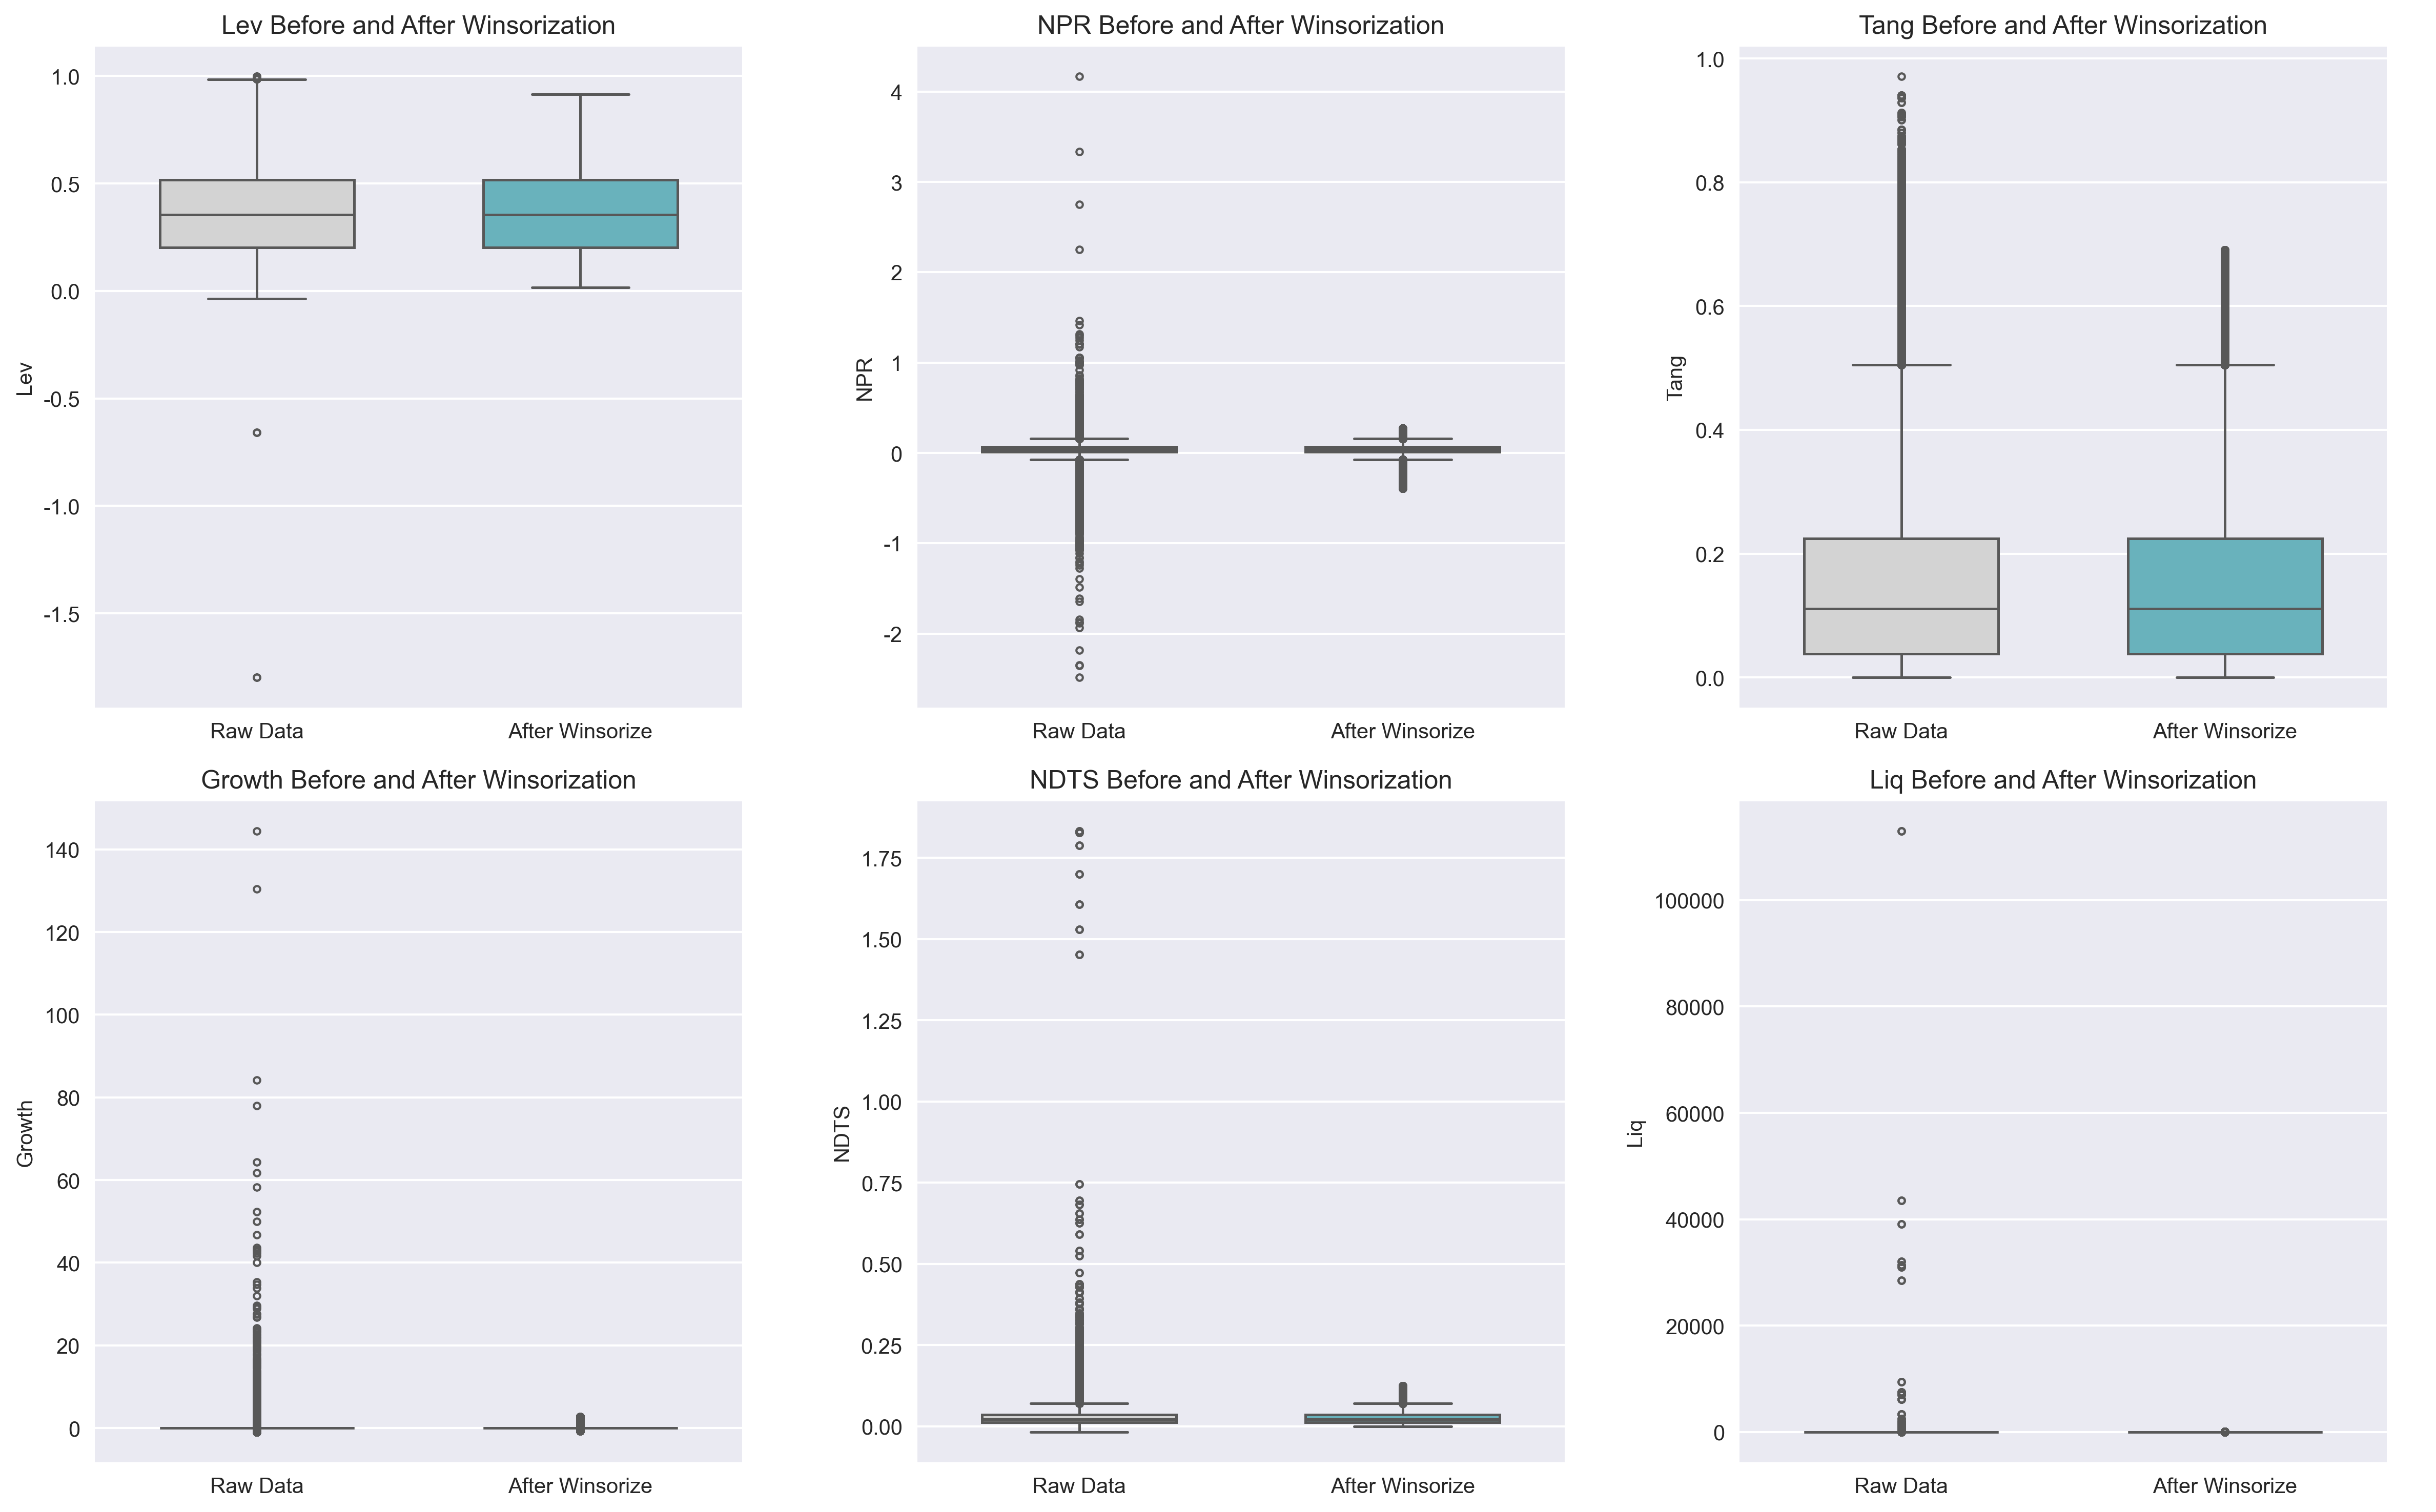

Outlier handling completed


In [6]:
import sys
sys.path.append('.')
from plot_config import (setup_academic_style, COLORS, styled_boxplot, 
                         save_figure, add_value_labels, remove_top_right_spines)

# Variables that need Winsorization
winsor_vars = ['Lev', 'NPR', 'Tang', 'Growth', 'NDTS']
if 'Liq' in df.columns:
    winsor_vars.append('Liq')

# First compute Winsorized data
for var in winsor_vars:
    df[f'{var}_winsor'] = df.groupby('year')[var].transform(
        lambda x: x.clip(lower=x.quantile(0.01), upper=x.quantile(0.99))
    )

# Plot Winsorize comparison
plt.figure(figsize=(16, 10))

for i, var in enumerate(winsor_vars):
    plt.subplot(2, 3, i+1)
    
    # Create comparison data
    compare_data = pd.DataFrame({
        'Raw Data': df[var],
        'After Winsorize': df[f'{var}_winsor']
    })
    
    # Use optimized boxplot
    ax = styled_boxplot(data=compare_data, palette=[COLORS['light_gray'], COLORS['teal']])
    plt.title(f'{var} Before and After Winsorization', fontsize=12)
    plt.ylabel(var, fontsize=10)
    
    # Adjust legend position
    plt.legend(title='', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
save_figure(plt.gcf(), os.path.join(OUTPUT_PATH, 'figures', 'winsorize_comparison.png'))
plt.show()

# Update variables to Winsorized values
for var in winsor_vars:
    df[var] = df[f'{var}_winsor']

print('Outlier handling completed')